<a href="https://colab.research.google.com/github/jferreira04-cloud/Calculo_num-rico_lobosco/blob/main/Atividade_2_C%C3%A1lculo_Num%C3%A9rico_Estabilidade__overflow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Maior float32: 3.4028235e+38
Maior float64: 1.7976931348623157e+308
dt=0.001, float32: 2000 passos sem overflow.
dt=0.002, float32: falha no passo 121, t=0.2420 s - overflow encountered in subtract
dt=0.001, float64: 2000 passos sem overflow.
dt=0.002, float64: falha no passo 917, t=1.8340 s - overflow encountered in add


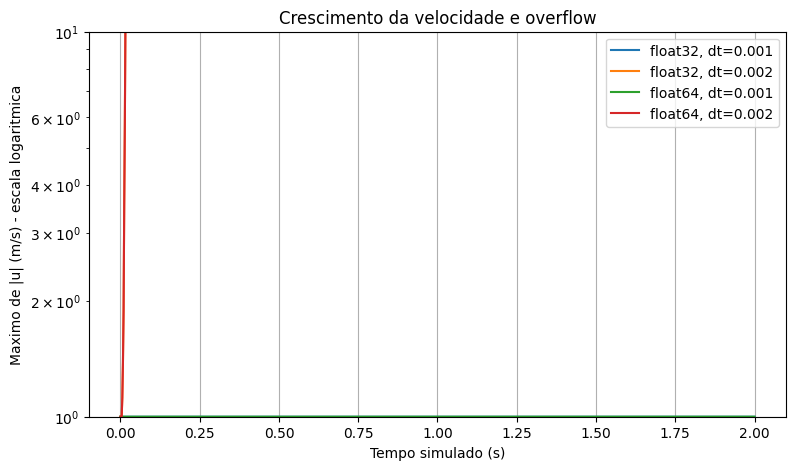

In [ ]:
"""
José Luiz de Oliveira Ferreira / TURMA: NB / Data: 02/09/2026

"""

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

def simular(dt, tipo=np.float32, passos=2000, pontos=21):
    """Simula difusao de velocidade e detecta falhas."""

    H = 0.01
    nu = 1e-4

    y = np.linspace(0, H, pontos)
    dy = H / (pontos - 1)

    # Coeficientes no tipo numerico escolhido.
    r = tipo(nu * dt / dy**2)
    dois = tipo(2)

    # Fluido parado e placa em y=0 em movimento.
    u = np.zeros(pontos, dtype=tipo)
    u[0] = tipo(1)

    tempos = [0.0]
    maximos = [float(np.max(np.abs(u)))]
    falha = None

    # Transforma avisos numericos em excecoes.
    with np.errstate(over="raise", invalid="raise"):
        for passo in range(1, passos + 1):
            try:
                novo = u.copy()

                # Atualiza o interior e preserva as paredes.
                novo[1:-1] = (
                    u[1:-1]
                    + r * (
                        u[2:] - dois * u[1:-1] + u[:-2]
                    )
                )

            except FloatingPointError as erro:
                falha = passo
                print(
                    f"dt={dt}, {tipo.__name__}: "
                    f"falha no passo {passo}, "
                    f"t={passo * dt:.4f} s - {erro}"
                )
                break

            u = novo
            tempos.append(passo * dt)
            maximos.append(float(np.max(np.abs(u))))

    if falha is None:
        print(
            f"dt={dt}, {tipo.__name__}: "
            f"{passos} passos sem overflow."
        )

    return {
        "y": y,
        "u": u,
        "tempos": tempos,
        "maximos": maximos,
        "r": float(r),
        "dy": dy,
        "falha": falha,
    }


H = 0.01
nu = 1e-4
U = 1.0

print("Maior float32:", np.finfo(np.float32).max)
print("Maior float64:", np.finfo(np.float64).max)

resultados = {}
for tipo in (np.float32, np.float64):
    for dt in (0.001, 0.002):
        nome = f"{tipo.__name__}, dt={dt}"
        resultados[nome] = simular(dt, tipo)
plt.figure(figsize=(9, 5))
for nome, resultado in resultados.items():
    plt.semilogy(
        resultado["tempos"],
        resultado["maximos"],
        label=nome
    )
plt.xlabel("Tempo simulado (s)")
plt.ylabel("Maximo de |u| (m/s) - escala logaritmica")
plt.title("Crescimento da velocidade e overflow")
plt.grid(True)
plt.legend()
plt.show()


In [ ]:
# Verificação de estabilidade
print("\n 1. Verificacao da estabilidade (21 pontos) ")
pontos = 21
dy = H / (pontos - 1)
dt_max = dy**2 / (2 * nu)
print(f"dy = {dy} m")
print(f"dt_max = {dt_max} s")

for dt in (0.001, 0.002):
    r = nu * dt / dy**2
    classificacao = "ESTAVEL (r <= 0.5)" if r <= 0.5 else "INSTAVEL (r > 0.5)"
    print(f"dt = {dt} s -> r = {r:.3f}  =>  {classificacao}")


 1. Verificacao da estabilidade (21 pontos) 
dy = 0.0005 m
dt_max = 0.0012499999999999998 s
dt = 0.001 s -> r = 0.400  =>  ESTAVEL (r <= 0.5)
dt = 0.002 s -> r = 0.800  =>  INSTAVEL (r > 0.5)


In [ ]:
# 2. Deteccao de overflow

print("\n 2. Detecção de overflow ")
resultados = {}
for tipo in (np.float32, np.float64):
    for dt in (0.001, 0.002):
        nome = f"{tipo.__name__}, dt={dt}"
        resultados[nome] = simular(dt, tipo)

print("\nTabela de resultados:")
print(f"{'tipo':<10}{'dt':<8}{'r':<8}{'overflow':<10}{'passo falha':<14}{'t falha (s)':<12}")
for nome, res in resultados.items():
    tipo_str, dt_str = nome.split(", ")
    dt = float(dt_str.replace("dt=", ""))
    overflow = "Sim" if res["falha"] is not None else "Nao"
    passo_falha = res["falha"] if res["falha"] is not None else "-"
    t_falha = f"{res['falha']*dt:.4f}" if res["falha"] is not None else "-"
    print(f"{tipo_str:<10}{dt:<8}{res['r']:<8.3f}{overflow:<10}{str(passo_falha):<14}{t_falha:<12}")


 2. Detecção de overflow 
dt=0.001, float32: 2000 passos sem overflow.
dt=0.002, float32: falha no passo 121, t=0.2420 s - overflow encountered in subtract
dt=0.001, float64: 2000 passos sem overflow.
dt=0.002, float64: falha no passo 917, t=1.8340 s - overflow encountered in add

Tabela de resultados:
tipo      dt      r       overflow  passo falha   t falha (s) 
float32   0.001   0.400   Nao       -             -           
float32   0.002   0.800   Sim       121           0.2420      
float64   0.001   0.400   Nao       -             -           
float64   0.002   0.800   Sim       917           1.8340      



 3. Grafico variando o passo de tempo (dt) 
dt=0.0003, float64: 2000 passos sem overflow.
dt=0.0006, float64: 2000 passos sem overflow.
dt=0.001, float64: 2000 passos sem overflow.
dt=0.00125, float64: 2000 passos sem overflow.
dt=0.0015, float64: 2000 passos sem overflow.
dt=0.002, float64: falha no passo 917, t=1.8340 s - overflow encountered in add
dt=0.0025, float64: falha no passo 656, t=1.6400 s - overflow encountered in add
dt=0.003, float64: falha no passo 539, t=1.6170 s - overflow encountered in add


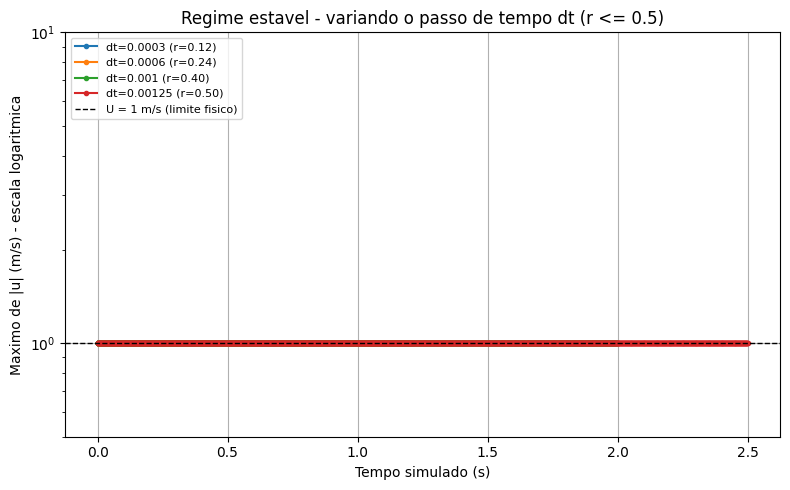

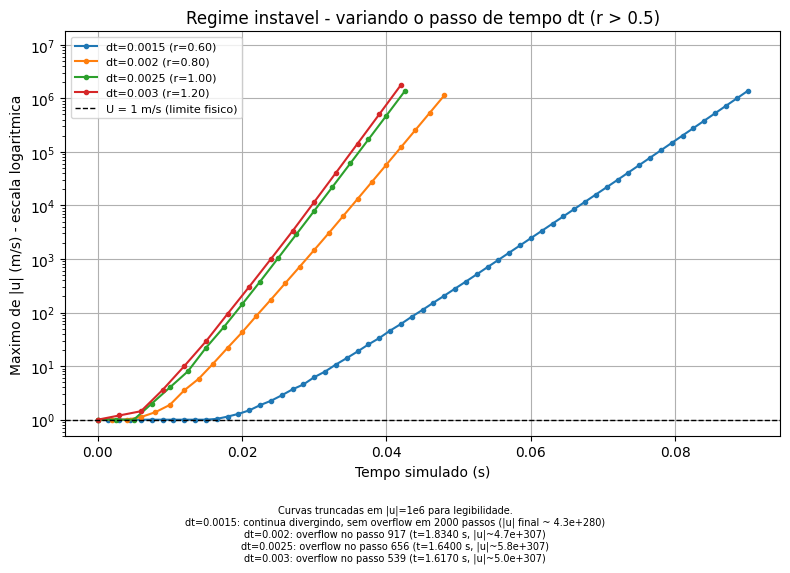

In [ ]:
# 3. Interpretacao fisica


print("\n 3. Grafico variando o passo de tempo (dt) ")

dts_estaveis = [0.0003, 0.0006, 0.001, 0.00125]     # r = 0.12, 0.24, 0.4, 0.5
dts_instaveis = [0.0015, 0.002, 0.0025, 0.003]      # r = 0.6, 0.8, 1.0, 1.2

resultados_dt = {}
for dt_var in dts_estaveis + dts_instaveis:
    resultados_dt[dt_var] = simular(dt_var, np.float64, passos=2000, pontos=21)


CORTE_VISUAL = 1e6


def truncar_para_plot(tempos, maximos):
    tempos = np.array(tempos)
    maximos = np.array(maximos)
    acima = np.where(maximos > CORTE_VISUAL)[0]
    if len(acima) == 0:
        return tempos, maximos
    corte = acima[0] + 1  # inclui 1 ponto acima do patamar, p/ mostrar a subida
    return tempos[:corte], maximos[:corte]


def plot_variando_dt(lista_dts, titulo, nome_arquivo):
    plt.figure(figsize=(8, 5))
    maior_valor_plotado = 1.0
    linhas_falha = []
    for dt_var in lista_dts:
        resultado = resultados_dt[dt_var]
        r_var = resultado["r"]
        t_plot, m_plot = truncar_para_plot(resultado["tempos"], resultado["maximos"])
        maior_valor_plotado = max(maior_valor_plotado, float(m_plot.max()))
        plt.semilogy(t_plot, m_plot, label=f"dt={dt_var} (r={r_var:.2f})", marker=".")
        if resultado["falha"] is not None:
            linhas_falha.append(
                f"dt={dt_var}: overflow no passo {resultado['falha']} "
                f"(t={resultado['falha']*dt_var:.4f} s, |u|~{resultado['maximos'][-1]:.1e})"
            )
        elif float(m_plot.max()) > CORTE_VISUAL:
            # Diverge (ja muito acima de U) mas nao chegou a estourar o
            # tipo numerico dentro dos passos testados - mostra que
            # instabilidade numerica != overflow (overflow pode vir depois).
            linhas_falha.append(
                f"dt={dt_var}: continua divergindo, sem overflow em "
                f"{len(resultado['maximos'])-1} passos (|u| final ~ "
                f"{resultado['maximos'][-1]:.1e})"
            )

    plt.axhline(1.0, color="k", linestyle="--", linewidth=1, label="U = 1 m/s (limite fisico)")
    plt.ylim(0.5, maior_valor_plotado * 10)
    plt.xlabel("Tempo simulado (s)")
    plt.ylabel("Maximo de |u| (m/s) - escala logaritmica")
    plt.title(titulo)
    plt.grid(True)
    plt.legend(loc="upper left", fontsize=8)

    if linhas_falha:
        plt.gcf().text(
            0.5, -0.02,
            "Curvas truncadas em |u|=1e6 para legibilidade.\n" + "\n".join(linhas_falha),
            ha="center", va="top", fontsize=7,
        )

    plt.tight_layout()
    plt.savefig(nome_arquivo, dpi=150, bbox_inches="tight")
    plt.show()


# Grafico 1: varios dt no regime estavel (r <= 0.5) -> "o caso que da certo"
plot_variando_dt(
    dts_estaveis,
    "Regime estavel - variando o passo de tempo dt (r <= 0.5)",
    "grafico_dt_estavel.png",
)

# Grafico 2: varios dt no regime instavel (r > 0.5) -> "o caso que da errado"
plot_variando_dt(
    dts_instaveis,
    "Regime instavel - variando o passo de tempo dt (r > 0.5)",
    "grafico_dt_instavel.png",
)


 3. Interpretacao fisica)  Explique por que o
crescimento observado no caso instável não representa o comportamento físico esperado.

   R: No gráfico do regime estável (r<=0.5), todas as curvas (mesmo a de r=0.5, no limite exato) ficam achatadas em U=1 m/s - fisicamente coerente, já que nenhum ponto do fluido pode se mover mais rápido que a placa que o arrasta, independente do dt escolhido dentro desse regime. No gráfico do regime instável (r>0.5), TODAS as curvas divergem exponencialmente, ultrapassando U por várias ordens de grandeza antes do overflow - e quanto maior o dt (maior o r), mais rápido (em poucos passos) a divergência acontece. Isso NÃO é um efeito físico, e sim instabilidade numérica: quando r>1/2, o coeficiente (1-2r) da atualização fica negativo e o esquema amplifica oscilações a cada passo, até saturar o tipo numérico. Caso particular (dt=0.0015, r=0.6, o mais perto do limite r=0.5): dentro dos 2000 passos testados ele diverge muito (chega a ~1e280), mas NÃO chega a dar overflow. Isso ilustra na prática o aviso do enunciado: instabilidade numérica e overflow não são sinônimos - a solução já está completamente incorreta bem antes (e às vezes sem nunca chegar a) estourar o tipo numérico.

 4. Capacidade de representação)
Compare os resultados com float32 e float64. A mudança de tipo numérico elimina a
instabilidade? Justifique a diferença no número de passos até a falha.

R:  A transição de float32 para float64 não elimina a instabilidade, pois a divergência exponencial é uma característica matemática intrínseca do esquema numérico quando a condição de estabilidade é violada ($r > 0,5$). O aumento no número de passos até a falha por overflow ocorre exclusivamente devido à maior faixa dinâmica do float64, que suporta valores até $\approx 1,8 \times 10^{308}$ antes de estourar, contra o limite de $\approx 3,4 \times 10^{38}$ do float32. Como a taxa de amplificação do erro a cada iteração é a mesma para ambos os tipos, o float64 simplesmente exige mais passos multiplicativos para que a amplitude atinja o seu limite de representação mais elevado, adiando o erro numérico sem corrigir o comportamento físico incorreto da simulação.

In [ ]:
 # 5. Refinamento da malha

print("\n 5. Refinamento da malha ")
pontos2 = 41
dy2 = H / (pontos2 - 1)
dt_max2 = dy2**2 / (2 * nu)
print(f"dy (41 pontos) = {dy2} m")
print(f"dt_max (41 pontos) = {dt_max2} s")

dt = 0.001
r2 = nu * dt / dy2**2
print(f"dt = {dt} s com 41 pontos -> r = {r2:.3f} "
      f"({'ESTAVEL' if r2 <= 0.5 else 'INSTAVEL'})")
res41_instavel = simular(dt, np.float64, passos=2000, pontos=pontos2)

dt_estavel = 0.0002
r2b = nu * dt_estavel / dy2**2
print(f"\ndt = {dt_estavel} s com 41 pontos -> r = {r2b:.3f} "
      f"({'ESTAVEL' if r2b <= 0.5 else 'INSTAVEL'})")
passos_estavel = 10000
res41_estavel = simular(dt_estavel, np.float64, passos=passos_estavel, pontos=pontos2)
print(f"Velocidade maxima final = {res41_estavel['maximos'][-1]:.6f} m/s "
      f"(t_final = {passos_estavel*dt_estavel:.2f} s)")



 5. Refinamento da malha 
dy (41 pontos) = 0.00025 m
dt_max (41 pontos) = 0.00031249999999999995 s
dt = 0.001 s com 41 pontos -> r = 1.600 (INSTAVEL)
dt=0.001, float64: falha no passo 426, t=0.4260 s - overflow encountered in subtract

dt = 0.0002 s com 41 pontos -> r = 0.320 (ESTAVEL)
dt=0.0002, float64: 10000 passos sem overflow.
Velocidade maxima final = 1.000000 m/s (t_final = 2.00 s)



 6. Perfil de velocidade vs. solucao estacionaria 
Escala de tempo difusiva: tau = H^2/nu = 1.0 s
dt=0.001, float64: 5000 passos sem overflow.


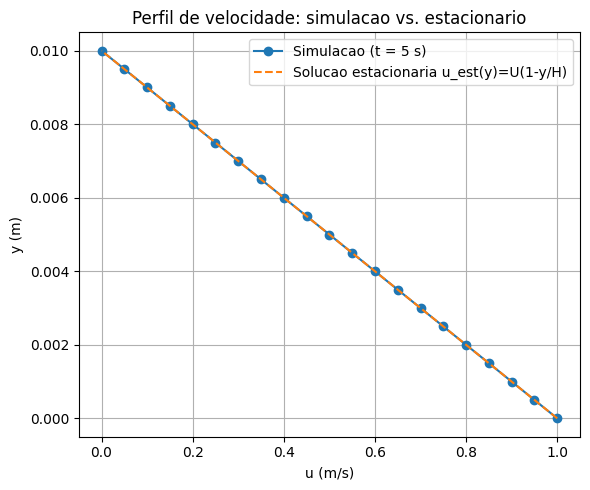


 E_infinito = max|u_i - u_est(y_i)| = 3.442e-15 m/s

Convergencia de E_infinito com o tempo simulado:


dt=0.001, float64: 500 passos sem overflow.
dt=0.001, float64: 1000 passos sem overflow.
dt=0.001, float64: 2000 passos sem overflow.
dt=0.001, float64: 3000 passos sem overflow.
dt=0.001, float64: 5000 passos sem overflow.


,Passos,t final (s),E_inf (m/s)
0,500,0.5,4.504e-03
1,1000,1.0,3.194e-05
2,2000,2.0,1.605e-09
3,3000,3.0,8.082e-14
4,5000,5.0,3.442e-15


In [ ]:
# 6. Verificacao do perfil de velocidade x solucao estacionaria

print("\n 6. Perfil de velocidade vs. solucao estacionaria ")
tau = H**2 / nu
print(f"Escala de tempo difusiva: tau = H^2/nu = {tau} s")

passos_longo = 5000  # t_final = 5 s = 5*tau
res_longo = simular(0.001, np.float64, passos=passos_longo, pontos=21)

y = res_longo["y"]
u_final = res_longo["u"]
u_est = U * (1 - y / H)
erro = np.abs(u_final - u_est)
E_inf = np.max(erro)

plt.figure(figsize=(6, 5))
plt.plot(u_final, y, "o-", label="Simulacao (t = 5 s)")
plt.plot(u_est, y, "--", label="Solucao estacionaria u_est(y)=U(1-y/H)")
plt.xlabel("u (m/s)")
plt.ylabel("y (m)")
plt.title("Perfil de velocidade: simulacao vs. estacionario")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("perfil_estacionario.png", dpi=150)
plt.show()

print(f"\n E_infinito = max|u_i - u_est(y_i)| = {E_inf:.3e} m/s")

print("\nConvergencia de E_infinito com o tempo simulado:")

print("\n")

linhas_convergencia = []
for passos in (500, 1000, 2000, 3000, 5000):
    res = simular(0.001, np.float64, passos=passos, pontos=21)
    u = res["u"]
    e_inf = np.max(np.abs(u - u_est))
    linhas_convergencia.append({
        "Passos": passos,
        "t final (s)": round(passos * 0.001, 3),
        "E_inf (m/s)": f"{e_inf:.3e}",
    })

tabela_convergencia = pd.DataFrame(linhas_convergencia)
tabela_convergencia

A comparação com o perfil estacionário (a solução física de regime permanente esperada para $t \to \infty$) expõe de forma direta o colapso da simulação. Em um esquema estável, a solução numérica converge suavemente para essa curva fixa de equilíbrio; já no regime instável ($r > 0,5$), as oscilações numéricas crescem exponencialmente e passam a dominar a resposta, fazendo com que o perfil simulado afaste-se drasticamente do estado estacionário em poucos passos de tempo e atinja amplitudes absurdas que violam totalmente o comportamento físico do sistema.

7. Conclusão) Explique a relação entre refinamento da malha, passo de tempo, instabilidade numérica e
overflow. Indique qual alteração corrigiu a causa da falha nesta simulação.

R: Refinar a malha (reduzir dy) sem reduzir dt de acordo com a nova condição de estabilidade (dt_max ~ dy²) reintroduz a instabilidade: passar de 21 para 41 pontos com o mesmo dt=0.001 s fez r subir de 0.4 para 1.6, e a simulação voltou a sofrer overflow. Instabilidade numérica e overflow não são sinônimos: quando r>1/2, o esquema amplifica oscilações a cada passo e a solução já fica fisicamente incorreta (|u|>U) muito antes de qualquer overflow, que é apenas a consequência tardia dessa amplificação. Mudar o tipo numérico (float32 -> float64) não corrige a causa: só adia o momento do overflow, pois a condição de estabilidade r<=1/2 não depende do tipo usado para armazenar u. A alteração que efetivamente corrige a falha, em todos os casos testados, é reduzir dt até satisfazer r = nudt/dy² <= 1/2. Com essa condição respeitada, a simulação permanece estável, |u| nunca excede U, e o perfil final converge para a solução estacionária u_est(y) = U(1 - y/H).